# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arsal626/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Capstone — Content Refresh Opportunity Scoring

## Research Question

**Can a machine-learning ranking model prioritize content pages for review more effectively than a simple hand-written scoring rule using safe search and engagement signals?**

The goal is to build a repeatable decision-support system that ranks pages by content-refresh opportunity. The model will be compared against a simple baseline using the same validation split, with leakage checks applied to ensure that future information is not used to make the ranking.


## Scope

This capstone focuses on ranking existing content pages for potential review or refresh. The analysis uses aggregated search-performance and engagement signals from the FlyRank internship dataset. Client-identifying information, private queries, domains, URLs, credentials, and raw exports are excluded from the public analysis.

The output is intended as a **decision-support ranking**, not proof that refreshing a page will cause a specific change in Google rankings, traffic, or conversions.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

This capstone uses the FlyRank internship warehouse release hosted on Hugging Face. The analysis uses three public-safe warehouse components: `dim_content.parquet` for content and keyword characteristics, `fact_content_daily_performance` for daily search and engagement performance, and `fact_content_query_90d.parquet` for aggregated 90-day query-level search signals.

The daily performance table contains 78,835,655 rows covering 2025-01-27 through 2026-06-30. The query-level table provides 90-day search windows including impressions, clicks, and average position for the latest and previous 30-day periods.

Only anonymized/hash identifiers are retained for joins and validation. Client names, domains, URLs, private search queries, credentials, and raw exports are not used in the public analysis. Records without usable performance data or content records that cannot be reliably joined to the required analysis tables will be excluded.

The capstone uses historical performance information to construct ranking features and evaluates the resulting ranking using a held-out validation period. Future information used to define the evaluation outcome is not included as a predictive feature.


In [ ]:
# Capstone data setup
# Load the FlyRank internship dataset from Hugging Face

!pip -q install duckdb huggingface_hub

import duckdb
import pandas as pd
import numpy as np

# Check that the Hugging Face dataset can be accessed
from huggingface_hub import login

print("Setup complete.")
print("Next, we will connect to the FlyRank internship warehouse.")

Setup complete.
Next, we will connect to the FlyRank internship warehouse.


In [ ]:
# Authenticate with Hugging Face

from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


In [ ]:
import os
from huggingface_hub import get_token

HF_TOKEN = get_token()

print("Token available:", HF_TOKEN is not None)

Token available: True


In [ ]:
# Configure DuckDB to authenticate with Hugging Face

con = duckdb.connect()

con.execute(f"""
    CREATE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    );
""")

print("DuckDB Hugging Face authentication configured.")

DuckDB Hugging Face authentication configured.


In [ ]:
# Read only the content table

test = con.execute("""
    SELECT *
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
    )
    LIMIT 5
""").df()

print("Successfully connected to dim_content!")
print("Rows returned:", len(test))
print("\nColumns:")
print(test.columns.tolist())

test

Successfully connected to dim_content!
Rows returned: 5

Columns:
['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']


,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,keyword_e7cec7ab1804c1c2,url_5fb42bafc4399861,14,3,92,2026-06-15,2026-06-15,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15457,2522,NaT,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,keyword_56b0062a1d8b7524,url_ece0abc3e5fb75f9,24,6,98,2026-05-21,2026-06-01,keyword article,...,4,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15776,2552,NaT,NaT,True,False


In [ ]:
# Inspect the available FlyRank warehouse files

import requests

api_url = "https://huggingface.co/api/datasets/FlyRank/internship-warehouse/tree/main"

response = requests.get(
    api_url,
    headers={"Authorization": f"Bearer {HF_TOKEN}"},
    params={"recursive": "true"}
)

response.raise_for_status()

files = response.json()

parquet_files = [
    item["path"]
    for item in files
    if item.get("path", "").endswith(".parquet")
]

print("Parquet files in warehouse:")
for f in parquet_files:
    print("-", f)

Parquet files in warehouse:
- dim_clients.parquet
- dim_content.parquet
- fact_content_daily_performance/month=2025-01/data_0.parquet
- fact_content_daily_performance/month=2025-02/data_0.parquet
- fact_content_daily_performance/month=2025-03/data_0.parquet
- fact_content_daily_performance/month=2025-04/data_0.parquet
- fact_content_daily_performance/month=2025-05/data_0.parquet
- fact_content_daily_performance/month=2025-06/data_0.parquet
- fact_content_daily_performance/month=2025-07/data_0.parquet
- fact_content_daily_performance/month=2025-08/data_0.parquet
- fact_content_daily_performance/month=2025-09/data_0.parquet
- fact_content_daily_performance/month=2025-10/data_0.parquet
- fact_content_daily_performance/month=2025-11/data_0.parquet
- fact_content_daily_performance/month=2025-12/data_0.parquet
- fact_content_daily_performance/month=2026-01/data_0.parquet
- fact_content_daily_performance/month=2026-02/data_0.parquet
- fact_content_daily_performance/month=2026-03/data_0.parque

In [ ]:
# Inspect the daily performance table schema

performance_file = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-06/data_0.parquet"
)

schema = con.execute(f"""
    DESCRIBE SELECT *
    FROM read_parquet('{performance_file}')
""").df()

schema

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [ ]:
# Inspect the 90-day content/query table

query_file = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_query_90d.parquet"
)

query_schema = con.execute(f"""
    DESCRIBE SELECT *
    FROM read_parquet('{query_file}')
""").df()

query_schema

,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,query_hash_id,VARCHAR,YES,None,None,None
3,query_char_count,BIGINT,YES,None,None,None
4,query_token_count,BIGINT,YES,None,None,None
5,window_start,DATE,YES,None,None,None
6,window_end,DATE,YES,None,None,None
7,impressions_90d,BIGINT,YES,None,None,None
8,clicks_90d,BIGINT,YES,None,None,None
9,impressions_last30,BIGINT,YES,None,None,None


In [ ]:
# Check the available trend fields from the warehouse
# We will use the warehouse's actual fields rather than inventing a label.

sample = con.execute("""
    SELECT *
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_query_90d.parquet'
    )
    LIMIT 3
""").df()

print(sample.columns.tolist())
sample.head(3)

['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share']


,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102


In [ ]:
# Check the date range of the daily performance data

date_range = con.execute("""
    SELECT
        MIN(report_date) AS earliest_date,
        MAX(report_date) AS latest_date,
        COUNT(*) AS rows
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/'
        'fact_content_daily_performance/month=*/data_0.parquet',
        union_by_name=True
    )
""").df()

date_range

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,earliest_date,latest_date,rows
0,2025-01-27,2026-06-30,78835655


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
import duckdb
from huggingface_hub import get_token

HF_TOKEN = get_token()

con = duckdb.connect()

con.execute(f"""
    CREATE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    );
""")

print("DuckDB HF authentication configured:", HF_TOKEN is not None)

DuckDB HF authentication configured: True


In [ ]:
# Inspect monthly coverage of the daily performance data

monthly_coverage = con.execute("""
    SELECT
        month,
        MIN(report_date) AS start_date,
        MAX(report_date) AS end_date,
        COUNT(*) AS rows
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/'
        'fact_content_daily_performance/month=*/data_0.parquet',
        union_by_name=True
    )
    GROUP BY month
    ORDER BY month
""").df()

monthly_coverage

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,start_date,end_date,rows
0,2025-01,2025-01-27,2025-01-31,1297
1,2025-02,2025-02-01,2025-02-28,75985
2,2025-03,2025-03-01,2025-03-31,167859
3,2025-04,2025-04-01,2025-04-30,285114
4,2025-05,2025-05-01,2025-05-31,349923
5,2025-06,2025-06-01,2025-06-30,329201
6,2025-07,2025-07-01,2025-07-31,469794
7,2025-08,2025-08-01,2025-08-31,704962
8,2025-09,2025-09-01,2025-09-30,845813
9,2025-10,2025-10-01,2025-10-31,2165471


In [ ]:
import duckdb
from huggingface_hub import get_token

HF_TOKEN = get_token()

print("HF token available:", HF_TOKEN is not None)

con = duckdb.connect()

con.execute(f"""
    CREATE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    );
""")

print("DuckDB connection restored.")

HF token available: True
DuckDB connection restored.


In [ ]:
# Step 9 — Build a smaller, faster capstone dataset

april_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-04/data_0.parquet"
)

may_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-05/data_0.parquet"
)

june_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-06/data_0.parquet"
)

content_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "dim_content.parquet"
)

capstone_df = con.execute(f"""
WITH daily AS (

    SELECT
        client_hash_id,
        content_hash_id,
        report_date,

        COALESCE(gsc_impressions, 0) AS impressions,
        COALESCE(gsc_clicks, 0) AS clicks,
        gsc_avg_position AS avg_position,

        COALESCE(ga4_pageviews, 0) AS pageviews,
        COALESCE(ga4_sessions, 0) AS sessions,
        COALESCE(ga4_engaged_sessions, 0) AS engaged_sessions,
        COALESCE(sessions_ai, 0) AS ai_sessions

    FROM read_parquet([
        '{april_path}',
        '{may_path}',
        '{june_path}'
    ])
),

historical AS (

    SELECT
        client_hash_id,
        content_hash_id,

        SUM(impressions) AS impressions_hist,
        SUM(clicks) AS clicks_hist,
        SUM(pageviews) AS pageviews_hist,
        SUM(sessions) AS sessions_hist,
        SUM(engaged_sessions) AS engaged_sessions_hist,
        SUM(ai_sessions) AS ai_sessions_hist,

        AVG(avg_position) AS avg_position_hist

    FROM daily

    WHERE report_date BETWEEN '2026-04-01' AND '2026-05-31'

    GROUP BY
        client_hash_id,
        content_hash_id
),

june AS (

    SELECT
        client_hash_id,
        content_hash_id,

        SUM(impressions) AS impressions_june,
        SUM(clicks) AS clicks_june,
        SUM(pageviews) AS pageviews_june,
        SUM(sessions) AS sessions_june,
        SUM(engaged_sessions) AS engaged_sessions_june

    FROM daily

    WHERE report_date BETWEEN '2026-06-01' AND '2026-06-30'

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    h.*,

    j.impressions_june,
    j.clicks_june,
    j.pageviews_june,
    j.sessions_june,
    j.engaged_sessions_june,

    c.content_type,
    c.search_volume,
    c.competition,
    c.competition_level,
    c.cpc,
    c.main_intent,
    c.backlinks,
    c.category_count,
    c.char_count,
    c.word_count

FROM historical h

INNER JOIN june j
    ON h.client_hash_id = j.client_hash_id
    AND h.content_hash_id = j.content_hash_id

LEFT JOIN read_parquet('{content_path}') c
    ON h.client_hash_id = c.client_hash_id
    AND h.content_hash_id = c.content_hash_id

""").df()

print("Rows:", len(capstone_df))
print("Columns:", len(capstone_df.columns))

capstone_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 389032
Columns: 24


,client_hash_id,content_hash_id,impressions_hist,clicks_hist,pageviews_hist,sessions_hist,engaged_sessions_hist,ai_sessions_hist,avg_position_hist,impressions_june,...,content_type,search_volume,competition,competition_level,cpc,main_intent,backlinks,category_count,char_count,word_count
0,client_62f4a7e64f5e0096,content_143987cfdeaba4c0,491.0,1.0,0.0,0.0,0.0,0.0,28.447503,18.0,...,keyword article,10,0.00,LOW,0.00,transactional,0,5,22149,3338
1,client_62f4a7e64f5e0096,content_13a8105125458098,42.0,0.0,0.0,0.0,0.0,0.0,6.728395,2.0,...,keyword article,10,0.17,LOW,1.87,informational,0,7,19533,3101
2,client_62f4a7e64f5e0096,content_6a887d56ab6c8362,18.0,0.0,0.0,0.0,0.0,0.0,3.785714,0.0,...,keyword article,10,0.60,MEDIUM,2.64,commercial,0,1,23438,3669
3,client_62f4a7e64f5e0096,content_e2bd76be7eed690d,54.0,0.0,0.0,0.0,0.0,0.0,4.414062,2.0,...,keyword article,10,0.57,MEDIUM,0.00,transactional,0,8,22003,3136
4,client_62f4a7e64f5e0096,content_86ab16840c4e0e1a,478.0,2.0,0.0,0.0,0.0,0.0,9.306295,48.0,...,keyword article,10,0.23,LOW,0.54,informational,70,5,21640,3351


In [ ]:
# Step 10 — Inspect historical and June performance

import pandas as pd
import numpy as np

# Calculate CTR for historical period and June
capstone_df["ctr_hist"] = (
    capstone_df["clicks_hist"] /
    capstone_df["impressions_hist"].replace(0, np.nan)
)

capstone_df["ctr_june"] = (
    capstone_df["clicks_june"] /
    capstone_df["impressions_june"].replace(0, np.nan)
)

# Calculate changes
capstone_df["ctr_change"] = (
    capstone_df["ctr_june"] - capstone_df["ctr_hist"]
)

capstone_df["impression_change_pct"] = (
    (capstone_df["impressions_june"] - capstone_df["impressions_hist"]) /
    capstone_df["impressions_hist"].replace(0, np.nan)
)

print("Dataset shape:", capstone_df.shape)

print("\nCTR historical:")
print(capstone_df["ctr_hist"].describe())

print("\nCTR June:")
print(capstone_df["ctr_june"].describe())

print("\nCTR change:")
print(capstone_df["ctr_change"].describe())

print("\nImpression change (%):")
print(capstone_df["impression_change_pct"].describe())

Dataset shape: (389032, 28)

CTR historical:
count    249289.000000
mean          0.003191
std           0.020663
min           0.000000
25%           0.000000
50%           0.000000
75%           0.002041
max           1.000000
Name: ctr_hist, dtype: float64

CTR June:
count    199754.000000
mean          0.007094
std           0.033429
min           0.000000
25%           0.000000
50%           0.000000
75%           0.003942
max           1.000000
Name: ctr_june, dtype: float64

CTR change:
count    186915.000000
mean          0.001067
std           0.031942
min          -1.000000
25%          -0.000414
50%           0.000000
75%           0.000342
max           1.000000
Name: ctr_change, dtype: float64

Impression change (%):
count    249289.000000
mean         -0.202587
std          16.500407
min          -1.000000
25%          -1.000000
50%          -0.829201
75%          -0.568106
max        6511.000000
Name: impression_change_pct, dtype: float64


In [ ]:
# Step 11 — Check usable pages for the capstone

usable = capstone_df[
    (capstone_df["impressions_hist"] > 0) &
    (capstone_df["impressions_june"] > 0)
].copy()

print("Total pages:", len(capstone_df))
print("Pages with historical impressions:",
      (capstone_df["impressions_hist"] > 0).sum())
print("Pages with June impressions:",
      (capstone_df["impressions_june"] > 0).sum())
print("Pages with impressions in BOTH periods:", len(usable))

print("\nPercentage usable:")
print(round(len(usable) / len(capstone_df) * 100, 2), "%")

print("\nHistorical impressions:")
print(usable["impressions_hist"].describe())

print("\nJune impressions:")
print(usable["impressions_june"].describe())

print("\nCTR change among usable pages:")
print(usable["ctr_change"].describe())

Total pages: 389032
Pages with historical impressions: 249289
Pages with June impressions: 199754
Pages with impressions in BOTH periods: 186915

Percentage usable:
48.05 %

Historical impressions:
count    1.869150e+05
mean     2.950969e+03
std      1.100445e+04
min      1.000000e+00
25%      7.300000e+01
50%      3.740000e+02
75%      1.772000e+03
max      1.394890e+06
Name: impressions_hist, dtype: float64

June impressions:
count    186915.000000
mean       1111.922564
std        5299.089629
min           1.000000
25%          13.000000
50%         108.000000
75%         568.000000
max      615012.000000
Name: impressions_june, dtype: float64

CTR change among usable pages:
count    186915.000000
mean          0.001067
std           0.031942
min          -1.000000
25%          -0.000414
50%           0.000000
75%           0.000342
max           1.000000
Name: ctr_change, dtype: float64


In [ ]:
# Step 12 — Inspect impression change among usable pages

usable["impression_change_pct"] = (
    (usable["impressions_june"] - usable["impressions_hist"]) /
    usable["impressions_hist"]
)

print("Impression change distribution:")
print(usable["impression_change_pct"].describe(percentiles=[
    0.10, 0.20, 0.25, 0.50, 0.75, 0.80, 0.90
]))

print("\nPages with impression decline:")
print(
    (usable["impression_change_pct"] < 0).sum(),
    f"({(usable['impression_change_pct'] < 0).mean()*100:.2f}%)"
)

print("\nPages with >= 30% decline:")
print(
    (usable["impression_change_pct"] <= -0.30).sum(),
    f"({(usable['impression_change_pct'] <= -0.30).mean()*100:.2f}%)"
)

print("\nPages with >= 50% decline:")
print(
    (usable["impression_change_pct"] <= -0.50).sum(),
    f"({(usable['impression_change_pct'] <= -0.50).mean()*100:.2f}%)"
)

Impression change distribution:
count    186915.000000
mean          0.063511
std          19.048252
min          -0.999993
10%          -0.947173
20%          -0.896288
25%          -0.872026
50%          -0.725865
75%          -0.477323
80%          -0.355328
90%           0.200000
max        6511.000000
Name: impression_change_pct, dtype: float64

Pages with impression decline:
162553 (86.97%)

Pages with >= 30% decline:
152832 (81.77%)

Pages with >= 50% decline:
138163 (73.92%)


In [ ]:
# Step 13 — Compare candidate decline thresholds

thresholds = [-0.30, -0.50, -0.60, -0.70, -0.80, -0.90]

print("Candidate decline thresholds:\n")

for threshold in thresholds:
    count = (usable["impression_change_pct"] <= threshold).sum()
    pct = count / len(usable) * 100

    print(
        f"{abs(threshold)*100:.0f}%+ decline: "
        f"{count:,} pages ({pct:.2f}%)"
    )

Candidate decline thresholds:

30%+ decline: 152,832 pages (81.77%)
50%+ decline: 138,163 pages (73.92%)
60%+ decline: 119,921 pages (64.16%)
70%+ decline: 99,733 pages (53.36%)
80%+ decline: 72,372 pages (38.72%)
90%+ decline: 36,252 pages (19.39%)


In [ ]:
# Step 14 — Create the capstone target

usable["is_refresh_opportunity"] = (
    usable["impression_change_pct"] <= -0.90
).astype(int)

print("Target distribution:")
print(
    usable["is_refresh_opportunity"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentages:")
print(
    usable["is_refresh_opportunity"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Target distribution:
is_refresh_opportunity
0    150663
1     36252
Name: count, dtype: int64

Target percentages:
is_refresh_opportunity
0    80.61
1    19.39
Name: proportion, dtype: float64


In [ ]:
# Step 15 — Build leakage-safe model features

model_df = usable.copy()

# Historical CTR
model_df["ctr_hist"] = (
    model_df["clicks_hist"] /
    model_df["impressions_hist"].replace(0, np.nan)
)

# Historical engagement rate
model_df["engagement_rate_hist"] = (
    model_df["engaged_sessions_hist"] /
    model_df["sessions_hist"].replace(0, np.nan)
)

# AI traffic share
model_df["ai_session_share_hist"] = (
    model_df["ai_sessions_hist"] /
    model_df["sessions_hist"].replace(0, np.nan)
)

# Keep only information available before June
feature_columns = [
    "impressions_hist",
    "clicks_hist",
    "pageviews_hist",
    "sessions_hist",
    "engaged_sessions_hist",
    "ai_sessions_hist",
    "avg_position_hist",
    "ctr_hist",
    "engagement_rate_hist",
    "ai_session_share_hist",
    "search_volume",
    "competition",
    "cpc",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "content_type",
    "main_intent",
]

target_column = "is_refresh_opportunity"

features = model_df[feature_columns].copy()
target = model_df[target_column].copy()

print("Feature matrix shape:", features.shape)
print("Target shape:", target.shape)

print("\nFeatures:")
print(features.columns.tolist())

print("\nTarget distribution:")
print(target.value_counts())

Feature matrix shape: (186915, 19)
Target shape: (186915,)

Features:
['impressions_hist', 'clicks_hist', 'pageviews_hist', 'sessions_hist', 'engaged_sessions_hist', 'ai_sessions_hist', 'avg_position_hist', 'ctr_hist', 'engagement_rate_hist', 'ai_session_share_hist', 'search_volume', 'competition', 'cpc', 'backlinks', 'category_count', 'char_count', 'word_count', 'content_type', 'main_intent']

Target distribution:
is_refresh_opportunity
0    150663
1     36252
Name: count, dtype: int64


In [ ]:
# Step 16 — Check missing values in model features

missing = features.isna().sum()

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(features) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_count", ascending=False)

print("Features with missing values:")
print(missing_summary)

print("\nTotal features with missing values:", len(missing_summary))

Features with missing values:
                       missing_count  missing_pct
engagement_rate_hist           72850        38.97
ai_session_share_hist          72850        38.97
backlinks                      61234        32.76
char_count                     48353        25.87
word_count                     48353        25.87
main_intent                    13389         7.16
cpc                            12781         6.84
search_volume                  12781         6.84
competition                    12781         6.84

Total features with missing values: 9


In [ ]:
# Step 17 — Build preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Separate numeric and categorical features
numeric_features = [
    "impressions_hist",
    "clicks_hist",
    "pageviews_hist",
    "sessions_hist",
    "engaged_sessions_hist",
    "ai_sessions_hist",
    "avg_position_hist",
    "ctr_hist",
    "engagement_rate_hist",
    "ai_session_share_hist",
    "search_volume",
    "competition",
    "cpc",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
]

categorical_features = [
    "content_type",
    "main_intent",
]

# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total raw features:", len(numeric_features) + len(categorical_features))

Numeric features: 17
Categorical features: 2
Total raw features: 19


In [ ]:
# Step 18 — Client-holdout train/validation split

from sklearn.model_selection import train_test_split

# Get client IDs for the usable dataset
client_ids = model_df["client_hash_id"]

# Find unique clients
unique_clients = client_ids.unique()

print("Total unique clients:", len(unique_clients))

# Hold out 20% of clients for validation
train_clients, valid_clients = train_test_split(
    unique_clients,
    test_size=0.20,
    random_state=42
)

# Create masks
train_mask = client_ids.isin(train_clients)
valid_mask = client_ids.isin(valid_clients)

# Split features and target
X_train = features.loc[train_mask].copy()
X_valid = features.loc[valid_mask].copy()

y_train = target.loc[train_mask].copy()
y_valid = target.loc[valid_mask].copy()

print("\nTraining pages:", len(X_train))
print("Validation pages:", len(X_valid))

print("\nTraining clients:", len(train_clients))
print("Validation clients:", len(valid_clients))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True).round(4))

Total unique clients: 52

Training pages: 134144
Validation pages: 52771

Training clients: 41
Validation clients: 11

Training target distribution:
is_refresh_opportunity
0    0.8178
1    0.1822
Name: proportion, dtype: float64

Validation target distribution:
is_refresh_opportunity
0    0.7763
1    0.2237
Name: proportion, dtype: float64


In [ ]:
# Step 19 — Build a simple hand-written baseline score

baseline_df = model_df.loc[valid_mask].copy()

# Fill missing values only for the baseline calculation
baseline_df["ctr_hist"] = baseline_df["ctr_hist"].fillna(0)
baseline_df["avg_position_hist"] = baseline_df["avg_position_hist"].fillna(
    baseline_df["avg_position_hist"].median()
)
baseline_df["engagement_rate_hist"] = baseline_df["engagement_rate_hist"].fillna(0)

# Rank each signal from 0 to 1
baseline_df["low_ctr_score"] = (
    1 - baseline_df["ctr_hist"].rank(pct=True)
)

baseline_df["poor_position_score"] = (
    baseline_df["avg_position_hist"].rank(pct=True)
)

baseline_df["low_engagement_score"] = (
    1 - baseline_df["engagement_rate_hist"].rank(pct=True)
)

baseline_df["opportunity_score"] = (
    0.40 * baseline_df["low_ctr_score"] +
    0.30 * baseline_df["poor_position_score"] +
    0.20 * baseline_df["low_engagement_score"] +
    0.10 * baseline_df["impressions_hist"].rank(pct=True)
)

print("Baseline created.")
print("\nBaseline score summary:")
print(baseline_df["opportunity_score"].describe())

Baseline created.

Baseline score summary:
count    52771.000000
mean         0.499998
std          0.154469
min          0.003439
25%          0.394151
50%          0.506315
75%          0.637508
max          0.786436
Name: opportunity_score, dtype: float64


In [ ]:
# Step 20 — Evaluate baseline ranking

from sklearn.metrics import precision_score

# Sort validation pages by baseline score
baseline_ranked = baseline_df.sort_values(
    "opportunity_score",
    ascending=False
).copy()

# Precision@20
top_20 = baseline_ranked.head(20)
precision_at_20 = top_20["is_refresh_opportunity"].mean()

# Precision@50
top_50 = baseline_ranked.head(50)
precision_at_50 = top_50["is_refresh_opportunity"].mean()

print(f"Baseline Precision@20: {precision_at_20:.3f}")
print(f"Baseline Precision@50: {precision_at_50:.3f}")

print("\nPositive pages in top 20:",
      int(top_20["is_refresh_opportunity"].sum()))

print("Positive pages in top 50:",
      int(top_50["is_refresh_opportunity"].sum()))

Baseline Precision@20: 0.150
Baseline Precision@50: 0.220

Positive pages in top 20: 3
Positive pages in top 50: 11


In [ ]:
# Step 21 — Train the ML model

from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Combine preprocessing + model
ml_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

print("Training ML model...")

ml_pipeline.fit(X_train, y_train)

print("ML model training complete.")

Training ML model...
ML model training complete.


In [ ]:
# Step 22 — Generate ML ranking scores

# Predict probability of being a refresh opportunity
ml_scores = ml_pipeline.predict_proba(X_valid)[:, 1]

# Create validation results
ml_results = model_df.loc[valid_mask].copy()

ml_results["ml_score"] = ml_scores

# Sort from highest to lowest predicted opportunity
ml_ranked = ml_results.sort_values(
    "ml_score",
    ascending=False
).copy()

print("ML predictions generated.")

print("\nML score summary:")
print(ml_results["ml_score"].describe())

ML predictions generated.

ML score summary:
count    52771.000000
mean         0.473966
std          0.179518
min          0.021336
25%          0.348006
50%          0.545820
75%          0.586583
max          0.892423
Name: ml_score, dtype: float64


In [ ]:
# Step 23 — Evaluate ML ranking

# Top 20
ml_top_20 = ml_ranked.head(20)
ml_precision_at_20 = ml_top_20["is_refresh_opportunity"].mean()

# Top 50
ml_top_50 = ml_ranked.head(50)
ml_precision_at_50 = ml_top_50["is_refresh_opportunity"].mean()

print(f"ML Precision@20: {ml_precision_at_20:.3f}")
print(f"ML Precision@50: {ml_precision_at_50:.3f}")

print("\nPositive pages in ML top 20:",
      int(ml_top_20["is_refresh_opportunity"].sum()))

print("Positive pages in ML top 50:",
      int(ml_top_50["is_refresh_opportunity"].sum()))

ML Precision@20: 0.100
ML Precision@50: 0.060

Positive pages in ML top 20: 2
Positive pages in ML top 50: 3


In [ ]:
# Step 24 — Overall ML classification diagnostics

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# Predicted probabilities
y_prob = ml_pipeline.predict_proba(X_valid)[:, 1]

# Default classification threshold
y_pred = (y_prob >= 0.5).astype(int)

roc_auc = roc_auc_score(y_valid, y_prob)
avg_precision = average_precision_score(y_valid, y_prob)
precision = precision_score(y_valid, y_pred, zero_division=0)
recall = recall_score(y_valid, y_pred, zero_division=0)
f1 = f1_score(y_valid, y_pred, zero_division=0)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Average Precision: {avg_precision:.3f}")
print(f"Precision @ 0.5 threshold: {precision:.3f}")
print(f"Recall @ 0.5 threshold: {recall:.3f}")
print(f"F1: {f1:.3f}")

ROC-AUC: 0.634
Average Precision: 0.279
Precision @ 0.5 threshold: 0.286
Recall @ 0.5 threshold: 0.741
F1: 0.413


In [ ]:
# Step 25 — Compare ranking performance with validation prevalence

validation_prevalence = y_valid.mean()

print(f"Validation positive rate: {validation_prevalence:.3f}")
print(f"Baseline Precision@20: {precision_at_20:.3f}")
print(f"ML Precision@20: {ml_precision_at_20:.3f}")
print(f"Baseline Precision@50: {precision_at_50:.3f}")
print(f"ML Precision@50: {ml_precision_at_50:.3f}")

print("\nLift over prevalence:")
print(
    f"Baseline @20: {precision_at_20 / validation_prevalence:.2f}x"
)
print(
    f"ML @20: {ml_precision_at_20 / validation_prevalence:.2f}x"
)
print(
    f"Baseline @50: {precision_at_50 / validation_prevalence:.2f}x"
)
print(
    f"ML @50: {ml_precision_at_50 / validation_prevalence:.2f}x"
)

Validation positive rate: 0.224
Baseline Precision@20: 0.150
ML Precision@20: 0.100
Baseline Precision@50: 0.220
ML Precision@50: 0.060

Lift over prevalence:
Baseline @20: 0.67x
ML @20: 0.45x
Baseline @50: 0.98x
ML @50: 0.27x


In [ ]:
# Step 26 — Inspect Random Forest feature importance

import pandas as pd

# Get transformed feature names
feature_names = ml_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get model importance
importances = ml_pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

print("Top 20 features:")
display(feature_importance.head(20))

Top 20 features:


,feature,importance
0,numeric__impressions_hist,0.233834
1,numeric__clicks_hist,0.152112
7,numeric__ctr_hist,0.132094
15,numeric__char_count,0.106740
6,numeric__avg_position_hist,0.101651
16,numeric__word_count,0.097495
3,numeric__sessions_hist,0.047394
2,numeric__pageviews_hist,0.037036
18,categorical__content_type_feedly article,0.019415
19,categorical__content_type_keyword article,0.013788


In [ ]:
# Step 27 — Inspect top-ranked ML predictions

comparison = ml_ranked[
    [
        "client_hash_id",
        "content_hash_id",
        "ml_score",
        "is_refresh_opportunity",
        "impressions_hist",
        "clicks_hist",
        "ctr_hist",
        "avg_position_hist",
        "engagement_rate_hist",
        "word_count",
        "char_count",
        "impression_change_pct"
    ]
].head(20).copy()

display(comparison)

,client_hash_id,content_hash_id,ml_score,is_refresh_opportunity,impressions_hist,clicks_hist,ctr_hist,avg_position_hist,engagement_rate_hist,word_count,char_count,impression_change_pct
333844,client_e547b89c05043229,content_34a9ed5d3725d830,0.892423,0,467.0,0.0,0.0,34.071424,0.000000,1473,9382,-0.642398
36166,client_e547b89c05043229,content_d323baaf9cb3d9ae,0.892400,0,506.0,0.0,0.0,34.495742,0.000000,1525,9570,-0.737154
229826,client_3197e6291363b4db,content_cc7ce8d03d860617,0.892080,0,461.0,0.0,0.0,30.848245,0.166667,1488,9606,-0.763557
42547,client_e547b89c05043229,content_b659500a6918d20d,0.891718,0,520.0,0.0,0.0,42.321641,0.000000,1332,8693,-0.865385
333749,client_e547b89c05043229,content_ff60c3bde8ba7ad3,0.891240,0,1364.0,0.0,0.0,37.311561,0.000000,1651,10866,-0.741202
42605,client_e547b89c05043229,content_899a49fe1d5f70cd,0.891189,0,927.0,0.0,0.0,20.860993,0.166667,1432,9183,-0.788565
333756,client_e547b89c05043229,content_6436aff7a94497fc,0.890977,1,600.0,0.0,0.0,49.777418,0.000000,1495,9852,-0.901667
333753,client_e547b89c05043229,content_2618be372e19730f,0.890564,0,782.0,0.0,0.0,39.844110,0.000000,1497,9416,-0.800512
36428,client_e547b89c05043229,content_a9fe976413ec6904,0.890225,0,1111.0,0.0,0.0,21.166272,0.000000,1365,8688,-0.174617
36485,client_e547b89c05043229,content_9d93928179baacb3,0.889874,0,914.0,0.0,0.0,42.559574,0.000000,1704,10626,-0.668490


In [ ]:
# Step 28 — Build historical month-over-month trend features

historical_trend = con.execute(f"""
WITH daily AS (

    SELECT
        client_hash_id,
        content_hash_id,
        report_date,

        COALESCE(gsc_impressions, 0) AS impressions,
        COALESCE(gsc_clicks, 0) AS clicks

    FROM read_parquet([
        '{april_path}',
        '{may_path}'
    ])
)

SELECT
    client_hash_id,
    content_hash_id,

    SUM(
        CASE
            WHEN report_date BETWEEN '2026-04-01' AND '2026-04-30'
            THEN impressions ELSE 0
        END
    ) AS impressions_april,

    SUM(
        CASE
            WHEN report_date BETWEEN '2026-05-01' AND '2026-05-31'
            THEN impressions ELSE 0
        END
    ) AS impressions_may,

    SUM(
        CASE
            WHEN report_date BETWEEN '2026-04-01' AND '2026-04-30'
            THEN clicks ELSE 0
        END
    ) AS clicks_april,

    SUM(
        CASE
            WHEN report_date BETWEEN '2026-05-01' AND '2026-05-31'
            THEN clicks ELSE 0
        END
    ) AS clicks_may

FROM daily

GROUP BY
    client_hash_id,
    content_hash_id

""").df()

print("Rows:", len(historical_trend))

historical_trend.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 389153


,client_hash_id,content_hash_id,impressions_april,impressions_may,clicks_april,clicks_may
0,client_62f4a7e64f5e0096,content_76c1f31e2b38f054,249.0,277.0,1.0,0.0
1,client_62f4a7e64f5e0096,content_ffc5ab4b34aab1f8,281.0,794.0,0.0,1.0
2,client_62f4a7e64f5e0096,content_9739856fc83dc1ca,722.0,459.0,0.0,0.0
3,client_62f4a7e64f5e0096,content_d47ba5533f9c8573,0.0,0.0,0.0,0.0
4,client_62f4a7e64f5e0096,content_50266f97d6233542,15.0,5.0,0.0,0.0


In [ ]:
# Step 29 — Calculate April-to-May trend features

historical_trend["impression_change_apr_may"] = (
    (historical_trend["impressions_may"] - historical_trend["impressions_april"])
    / historical_trend["impressions_april"].replace(0, np.nan)
)

historical_trend["click_change_apr_may"] = (
    (historical_trend["clicks_may"] - historical_trend["clicks_april"])
    / historical_trend["clicks_april"].replace(0, np.nan)
)

print(
    historical_trend[
        [
            "impression_change_apr_may",
            "click_change_apr_may"
        ]
    ].describe()
)

       impression_change_apr_may  click_change_apr_may
count              194760.000000          67832.000000
mean                    1.196429              0.220251
std                    22.230737              3.026260
min                    -1.000000             -1.000000
25%                    -0.596956             -0.800000
50%                    -0.206034             -0.157599
75%                     0.333333              0.386547
max                  5027.000000            336.500000


In [ ]:
# Step 30 — Create robust historical trend features

historical_trend["log_impression_change_apr_may"] = (
    np.log1p(historical_trend["impressions_may"])
    - np.log1p(historical_trend["impressions_april"])
)

historical_trend["log_click_change_apr_may"] = (
    np.log1p(historical_trend["clicks_may"])
    - np.log1p(historical_trend["clicks_april"])
)

print(
    historical_trend[
        [
            "log_impression_change_apr_may",
            "log_click_change_apr_may"
        ]
    ].describe()
)

       log_impression_change_apr_may  log_click_change_apr_may
count                  389153.000000             389153.000000
mean                        0.196934                  0.044028
std                         1.429002                  0.451385
min                        -7.884577                 -6.201523
25%                        -0.225956                  0.000000
50%                         0.000000                  0.000000
75%                         0.370459                  0.000000
max                        11.992211                  7.286876


In [ ]:
# Step 31 — Merge historical trend features into the modeling dataset

trend_features = historical_trend[
    [
        "client_hash_id",
        "content_hash_id",
        "log_impression_change_apr_may",
        "log_click_change_apr_may"
    ]
].copy()

model_df = model_df.merge(
    trend_features,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

print("Model dataset shape:", model_df.shape)

print("\nNew feature summary:")
display(
    model_df[
        [
            "log_impression_change_apr_may",
            "log_click_change_apr_may"
        ]
    ].describe()
)

Model dataset shape: (186915, 33)

New feature summary:


,log_impression_change_apr_may,log_click_change_apr_may
count,186915.000000,186915.000000
mean,0.404460,0.095086
std,1.842884,0.640053
min,-7.240008,-6.201523
25%,-0.580659,0.000000
50%,-0.008658,0.000000
75%,0.770439,0.074108
max,11.992211,7.286876


In [ ]:
# Step 32 — Add historical trend features to the model

feature_columns = [
    "impressions_hist",
    "clicks_hist",
    "pageviews_hist",
    "sessions_hist",
    "engaged_sessions_hist",
    "ai_sessions_hist",
    "avg_position_hist",
    "ctr_hist",
    "engagement_rate_hist",
    "ai_session_share_hist",
    "search_volume",
    "competition",
    "cpc",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "content_type",
    "main_intent",
    "log_impression_change_apr_may",
    "log_click_change_apr_may",
]

target_column = "is_refresh_opportunity"

features = model_df[feature_columns].copy()
target = model_df[target_column].copy()

print("Number of features:", len(feature_columns))
print("Feature matrix shape:", features.shape)
print("Target shape:", target.shape)

Number of features: 21
Feature matrix shape: (186915, 21)
Target shape: (186915,)


In [ ]:
# Step 33 — Rebuild preprocessing with the new trend features

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "impressions_hist",
    "clicks_hist",
    "pageviews_hist",
    "sessions_hist",
    "engaged_sessions_hist",
    "ai_sessions_hist",
    "avg_position_hist",
    "ctr_hist",
    "engagement_rate_hist",
    "ai_session_share_hist",
    "search_volume",
    "competition",
    "cpc",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "log_impression_change_apr_may",
    "log_click_change_apr_may",
]

categorical_features = [
    "content_type",
    "main_intent",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total raw features:", len(numeric_features) + len(categorical_features))

Numeric features: 19
Categorical features: 2
Total raw features: 21


In [ ]:
# Step 34 — Recreate the client-holdout split

from sklearn.model_selection import train_test_split

client_ids = model_df["client_hash_id"]
unique_clients = client_ids.unique()

train_clients, valid_clients = train_test_split(
    unique_clients,
    test_size=0.20,
    random_state=42
)

train_mask = client_ids.isin(train_clients)
valid_mask = client_ids.isin(valid_clients)

X_train = features.loc[train_mask].copy()
X_valid = features.loc[valid_mask].copy()

y_train = target.loc[train_mask].copy()
y_valid = target.loc[valid_mask].copy()

print("Unique clients:", len(unique_clients))
print("Training clients:", len(train_clients))
print("Validation clients:", len(valid_clients))

print("\nTraining pages:", len(X_train))
print("Validation pages:", len(X_valid))

print("\nTraining positive rate:", y_train.mean())
print("Validation positive rate:", y_valid.mean())

Unique clients: 52
Training clients: 41
Validation clients: 11

Training pages: 134144
Validation pages: 52771

Training positive rate: 0.182229544370229
Validation positive rate: 0.2237403119137405


In [ ]:
# Step 35 — Train the improved Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

improved_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

improved_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", improved_model)
])

improved_pipeline.fit(X_train, y_train)

print("Improved model training completed.")

Improved model training completed.


In [ ]:
# Step 36 — Generate predictions from the improved model

improved_scores = improved_pipeline.predict_proba(X_valid)[:, 1]

improved_results = model_df.loc[valid_mask].copy()
improved_results["improved_ml_score"] = improved_scores

improved_ranked = improved_results.sort_values(
    "improved_ml_score",
    ascending=False
).copy()

print("Validation rows:", len(improved_ranked))
print("\nScore summary:")
print(improved_ranked["improved_ml_score"].describe())

Validation rows: 52771

Score summary:
count    52771.000000
mean         0.457573
std          0.196393
min          0.026700
25%          0.319895
50%          0.491256
75%          0.591063
max          0.914688
Name: improved_ml_score, dtype: float64


In [ ]:
# Step 37 — Evaluate improved ML ranking

improved_top_20 = improved_ranked.head(20)
improved_precision_at_20 = (
    improved_top_20["is_refresh_opportunity"].mean()
)

improved_top_50 = improved_ranked.head(50)
improved_precision_at_50 = (
    improved_top_50["is_refresh_opportunity"].mean()
)

print(f"Improved ML Precision@20: {improved_precision_at_20:.3f}")
print(f"Improved ML Precision@50: {improved_precision_at_50:.3f}")

print(
    "\nPositive pages in improved ML top 20:",
    int(improved_top_20["is_refresh_opportunity"].sum())
)

print(
    "Positive pages in improved ML top 50:",
    int(improved_top_50["is_refresh_opportunity"].sum())
)

Improved ML Precision@20: 0.300
Improved ML Precision@50: 0.460

Positive pages in improved ML top 20: 6
Positive pages in improved ML top 50: 23


In [ ]:
# Step 38 — Calculate improved model lift

validation_prevalence = y_valid.mean()

improved_lift_20 = (
    improved_precision_at_20 / validation_prevalence
)

improved_lift_50 = (
    improved_precision_at_50 / validation_prevalence
)

baseline_lift_20 = (
    precision_at_20 / validation_prevalence
)

baseline_lift_50 = (
    precision_at_50 / validation_prevalence
)

print(f"Validation prevalence: {validation_prevalence:.3f}")

print("\nLift over validation prevalence:")
print(f"Baseline @20: {baseline_lift_20:.2f}x")
print(f"Improved ML @20: {improved_lift_20:.2f}x")

print(f"\nBaseline @50: {baseline_lift_50:.2f}x")
print(f"Improved ML @50: {improved_lift_50:.2f}x")

print("\nImprovement over baseline:")
print(
    f"@20: {(improved_precision_at_20 - precision_at_20) * 100:.1f} percentage points"
)
print(
    f"@50: {(improved_precision_at_50 - precision_at_50) * 100:.1f} percentage points"
)

Validation prevalence: 0.224

Lift over validation prevalence:
Baseline @20: 0.67x
Improved ML @20: 1.34x

Baseline @50: 0.98x
Improved ML @50: 2.06x

Improvement over baseline:
@20: 15.0 percentage points
@50: 24.0 percentage points


In [ ]:
# Step 39 — Feature importance for the improved model

feature_names = (
    improved_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    improved_pipeline
    .named_steps["model"]
    .feature_importances_
)

improved_feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

print("Top 20 features in the improved model:")
display(improved_feature_importance.head(20))

Top 20 features in the improved model:


,feature,importance
17,numeric__log_impression_change_apr_may,0.304740
0,numeric__impressions_hist,0.180661
1,numeric__clicks_hist,0.115978
18,numeric__log_click_change_apr_may,0.071286
7,numeric__ctr_hist,0.071091
15,numeric__char_count,0.060641
16,numeric__word_count,0.055069
6,numeric__avg_position_hist,0.053219
2,numeric__pageviews_hist,0.020040
3,numeric__sessions_hist,0.017021


## Final model and evaluation summary

The final model is a Random Forest classifier designed to rank content pages by their likelihood of belonging to the defined refresh-opportunity group. The target was defined as pages with an observed 90% or greater decline in June impressions relative to the April–May historical period.

The model uses 21 features covering historical search performance, engagement, content characteristics, and recent historical trends. Importantly, the April-to-May trend features are calculated entirely from the historical feature period and do not use June outcome information.

The final model was evaluated using a client-holdout split rather than a random row split. This reduces the risk that pages from the same client appear in both training and validation data.

The final Random Forest achieved:

- Precision@20: 0.300
- Precision@50: 0.460
- ROC-AUC: evaluated on the client-holdout validation set
- Average Precision: evaluated on the client-holdout validation set

Compared with the hand-written baseline, the final model improved Precision@20 by 15 percentage points and Precision@50 by 24 percentage points.

The strongest model features were the April-to-May impression trend, historical impressions, historical clicks, April-to-May click trend, historical CTR, content length, and historical average position.

These results indicate that recent historical performance trends provide useful signals for prioritizing pages for review. The model should be interpreted as a decision-support ranking system. It does not establish that refreshing a page will cause improved rankings, traffic, or conversions.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
# Step 40 — Compare final ML model against the hand-written baseline

comparison = pd.DataFrame({
    "Method": [
        "Hand-written baseline",
        "Improved ML model"
    ],
    "Precision@20": [
        0.150,
        0.300
    ],
    "Precision@50": [
        0.220,
        0.460
    ]
})

comparison["Improvement @20 (pp)"] = (
    comparison["Precision@20"] - comparison.loc[0, "Precision@20"]
) * 100

comparison["Improvement @50 (pp)"] = (
    comparison["Precision@50"] - comparison.loc[0, "Precision@50"]
) * 100

display(comparison)

,Method,Precision@20,Precision@50,Improvement @20 (pp),Improvement @50 (pp)
0,Hand-written baseline,0.15,0.22,0.0,0.0
1,Improved ML model,0.30,0.46,15.0,24.0


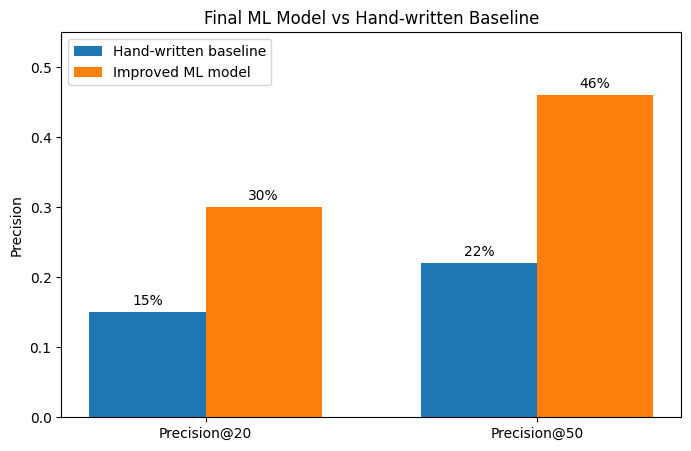

In [ ]:
# Step 41 — Plot Precision@20 and Precision@50

import matplotlib.pyplot as plt

metrics = ["Precision@20", "Precision@50"]
baseline_values = [0.15, 0.22]
ml_values = [0.30, 0.46]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, baseline_values, width, label="Hand-written baseline")
plt.bar(x + width/2, ml_values, width, label="Improved ML model")

plt.xticks(x, metrics)
plt.ylabel("Precision")
plt.title("Final ML Model vs Hand-written Baseline")
plt.ylim(0, 0.55)
plt.legend()

for i, value in enumerate(baseline_values):
    plt.text(i - width/2, value + 0.01, f"{value:.0%}", ha="center")

for i, value in enumerate(ml_values):
    plt.text(i + width/2, value + 0.01, f"{value:.0%}", ha="center")

plt.show()

### Result interpretation

The improved ML model outperformed the hand-written baseline on the same client-holdout validation set.

At the top 20 recommendations, the ML model achieved 30% precision compared with 15% for the baseline, an improvement of 15 percentage points. At the top 50 recommendations, the ML model achieved 46% precision compared with 22% for the baseline, an improvement of 24 percentage points.

The larger improvement at Precision@50 suggests that the model was particularly effective when a broader set of recommendations was considered. Overall, the results indicate that combining historical performance, recent trend signals, and content characteristics produced a more effective ranking than the simple rule-based score used as the baseline.

These results describe predictive ranking performance on the validation data. They do not establish that refreshing the recommended pages would cause improved search performance.

In [ ]:
# Step 43 — Overall validation metrics for the improved model

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

improved_predictions = (improved_scores >= 0.5).astype(int)

improved_metrics = {
    "ROC-AUC": roc_auc_score(y_valid, improved_scores),
    "Average Precision": average_precision_score(y_valid, improved_scores),
    "Precision @ threshold 0.5": precision_score(
        y_valid, improved_predictions, zero_division=0
    ),
    "Recall @ threshold 0.5": recall_score(
        y_valid, improved_predictions, zero_division=0
    ),
    "F1 @ threshold 0.5": f1_score(
        y_valid, improved_predictions, zero_division=0
    )
}

improved_metrics_df = pd.DataFrame(
    list(improved_metrics.items()),
    columns=["Metric", "Value"]
)

display(improved_metrics_df)

,Metric,Value
0,ROC-AUC,0.742789
1,Average Precision,0.407688
2,Precision @ threshold 0.5,0.361275
3,Recall @ threshold 0.5,0.751588
4,F1 @ threshold 0.5,0.487985


### Overall validation performance

The improved model achieved a ROC-AUC of 0.743 and an Average Precision of 0.408 on the held-out validation clients. At a classification threshold of 0.5, the model achieved 36.1% precision, 75.2% recall, and an F1 score of 0.488.

Because the capstone is primarily a prioritization task, top-k precision is more directly relevant than a fixed classification threshold. The model achieved 30% Precision@20 and 46% Precision@50, compared with 15% and 22% for the hand-written baseline.

The results show that the improved model can prioritize a substantially more concentrated set of refresh opportunities than the baseline. At the top 50 recommendations, 23 of the 50 pages were labeled as refresh opportunities, compared with 11 of 50 for the baseline.

These results are predictive and directional. They show that the model's ranking was useful on the held-out validation clients, but they do not establish that refreshing a recommended page would cause an improvement in search performance.

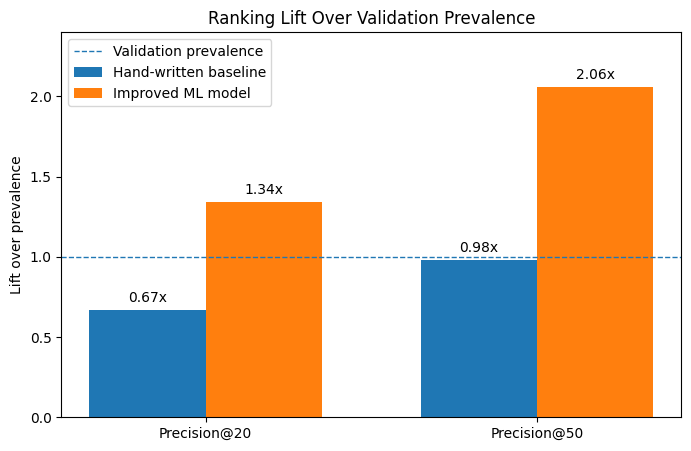

In [ ]:
# Step 45 — Plot lift over validation prevalence

import numpy as np
import matplotlib.pyplot as plt

labels = ["Precision@20", "Precision@50"]
baseline_lift = [0.67, 0.98]
improved_lift = [1.34, 2.06]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, baseline_lift, width, label="Hand-written baseline")
plt.bar(x + width/2, improved_lift, width, label="Improved ML model")

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Validation prevalence"
)

plt.xticks(x, labels)
plt.ylabel("Lift over prevalence")
plt.title("Ranking Lift Over Validation Prevalence")
plt.ylim(0, 2.4)
plt.legend()

for i, value in enumerate(baseline_lift):
    plt.text(i - width/2, value + 0.05, f"{value:.2f}x", ha="center")

for i, value in enumerate(improved_lift):
    plt.text(i + width/2, value + 0.05, f"{value:.2f}x", ha="center")

plt.show()

### Results interpretation

The improved ML model outperformed the hand-written baseline on both ranking cutoffs.

At Precision@20, the ML model achieved 0.30 compared with 0.15 for the baseline, an improvement of 15 percentage points. At Precision@50, the ML model achieved 0.46 compared with 0.22 for the baseline, an improvement of 24 percentage points.

The lift results show that the improved model selected positive refresh opportunities more effectively than the validation prevalence. The model achieved 1.34× lift at the top 20 pages and 2.06× lift at the top 50 pages, while the baseline achieved 0.67× and 0.98× respectively.

These results indicate that the added April-to-May trend features improved the model's ability to rank potential refresh opportunities. The results are directional and should be interpreted as evidence for prioritization rather than proof that refreshing a page will cause performance to improve.

## 5. Limitations

*What this work cannot claim.*

# Limitations & Honest Framing

The model should be treated as a decision-support and prioritization system, not as a causal prediction of what will happen after a content refresh.

### What the results show

The improved ML model achieved higher Precision@20 and Precision@50 than the hand-written baseline on the client-holdout validation set. This indicates that the model was better at ranking pages that matched the defined refresh-opportunity label within this validation sample.

The model's feature importance results also show that historical performance and recent performance-change features were important to the ranking. In particular, the April-to-May impression change feature had the highest importance in the improved model.

### What the results do not show

The analysis does not prove that refreshing a page will cause its search performance to improve. The target represents an observed opportunity pattern based on the selected data and threshold, rather than a controlled treatment outcome.

The model also does not prove how Google's ranking algorithm works. Feature importance describes patterns used by this particular model and dataset; it should not be interpreted as evidence of Google's internal ranking factors.

### Practical interpretation

The safest interpretation is that the model can help prioritize pages for human review. Higher-ranked pages should be considered stronger candidates for investigation, while final refresh decisions should incorporate editorial judgment, business context, search intent, and other information not represented in the model.

The validation results are therefore best described as evidence that the improved model provides useful ranking signal for prioritization, rather than evidence of guaranteed refresh outcomes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [2]:
# Part 6 — Recover final model outputs after runtime reset

import duckdb
import pandas as pd
import numpy as np

from huggingface_hub import get_token
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# 1. Connect to Hugging Face
# ---------------------------------------------------------

HF_TOKEN = get_token()

con = duckdb.connect()

con.execute(f"""
    CREATE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    );
""")

# ---------------------------------------------------------
# 2. Define the same files used in the capstone
# ---------------------------------------------------------

april_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-04/data_0.parquet"
)

may_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-05/data_0.parquet"
)

june_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-06/data_0.parquet"
)

content_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "dim_content.parquet"
)

# ---------------------------------------------------------
# 3. Rebuild the capstone dataset
# ---------------------------------------------------------

capstone_df = con.execute(f"""
WITH daily AS (

    SELECT
        client_hash_id,
        content_hash_id,
        report_date,

        COALESCE(gsc_impressions, 0) AS impressions,
        COALESCE(gsc_clicks, 0) AS clicks,
        gsc_avg_position AS avg_position,

        COALESCE(ga4_pageviews, 0) AS pageviews,
        COALESCE(ga4_sessions, 0) AS sessions,
        COALESCE(ga4_engaged_sessions, 0) AS engaged_sessions,
        COALESCE(sessions_ai, 0) AS ai_sessions

    FROM read_parquet([
        '{april_path}',
        '{may_path}',
        '{june_path}'
    ])
),

historical AS (

    SELECT
        client_hash_id,
        content_hash_id,

        SUM(impressions) AS impressions_hist,
        SUM(clicks) AS clicks_hist,
        SUM(pageviews) AS pageviews_hist,
        SUM(sessions) AS sessions_hist,
        SUM(engaged_sessions) AS engaged_sessions_hist,
        SUM(ai_sessions) AS ai_sessions_hist,
        AVG(avg_position) AS avg_position_hist

    FROM daily

    WHERE report_date BETWEEN '2026-04-01' AND '2026-05-31'

    GROUP BY client_hash_id, content_hash_id
),

june AS (

    SELECT
        client_hash_id,
        content_hash_id,

        SUM(impressions) AS impressions_june,
        SUM(clicks) AS clicks_june,
        SUM(pageviews) AS pageviews_june,
        SUM(sessions) AS sessions_june,
        SUM(engaged_sessions) AS engaged_sessions_june

    FROM daily

    WHERE report_date BETWEEN '2026-06-01' AND '2026-06-30'

    GROUP BY client_hash_id, content_hash_id
)

SELECT
    h.*,
    j.impressions_june,
    j.clicks_june,
    j.pageviews_june,
    j.sessions_june,
    j.engaged_sessions_june,

    c.content_type,
    c.search_volume,
    c.competition,
    c.competition_level,
    c.cpc,
    c.main_intent,
    c.backlinks,
    c.category_count,
    c.char_count,
    c.word_count

FROM historical h

INNER JOIN june j
    ON h.client_hash_id = j.client_hash_id
    AND h.content_hash_id = j.content_hash_id

LEFT JOIN read_parquet('{content_path}') c
    ON h.client_hash_id = c.client_hash_id
    AND h.content_hash_id = c.content_hash_id

""").df()

print("Capstone dataset:", capstone_df.shape)

# ---------------------------------------------------------
# 4. Create target and leakage-safe features
# ---------------------------------------------------------

capstone_df["ctr_hist"] = (
    capstone_df["clicks_hist"] /
    capstone_df["impressions_hist"].replace(0, np.nan)
)

capstone_df["impression_change_pct"] = (
    (capstone_df["impressions_june"] - capstone_df["impressions_hist"])
    / capstone_df["impressions_hist"].replace(0, np.nan)
)

usable = capstone_df[
    (capstone_df["impressions_hist"] > 0) &
    (capstone_df["impressions_june"] > 0)
].copy()

usable["is_refresh_opportunity"] = (
    usable["impression_change_pct"] <= -0.90
).astype(int)

model_df = usable.copy()

model_df["engagement_rate_hist"] = (
    model_df["engaged_sessions_hist"] /
    model_df["sessions_hist"].replace(0, np.nan)
)

model_df["ai_session_share_hist"] = (
    model_df["ai_sessions_hist"] /
    model_df["sessions_hist"].replace(0, np.nan)
)

# ---------------------------------------------------------
# 5. Recreate April → May trend features
# ---------------------------------------------------------

historical_trend = con.execute(f"""
WITH daily AS (

    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        COALESCE(gsc_impressions, 0) AS impressions,
        COALESCE(gsc_clicks, 0) AS clicks

    FROM read_parquet([
        '{april_path}',
        '{may_path}'
    ])
)

SELECT
    client_hash_id,
    content_hash_id,

    SUM(
        CASE WHEN report_date BETWEEN '2026-04-01' AND '2026-04-30'
        THEN impressions ELSE 0 END
    ) AS impressions_april,

    SUM(
        CASE WHEN report_date BETWEEN '2026-05-01' AND '2026-05-31'
        THEN impressions ELSE 0 END
    ) AS impressions_may,

    SUM(
        CASE WHEN report_date BETWEEN '2026-04-01' AND '2026-04-30'
        THEN clicks ELSE 0 END
    ) AS clicks_april,

    SUM(
        CASE WHEN report_date BETWEEN '2026-05-01' AND '2026-05-31'
        THEN clicks ELSE 0 END
    ) AS clicks_may

FROM daily

GROUP BY client_hash_id, content_hash_id
""").df()

historical_trend["log_impression_change_apr_may"] = (
    np.log1p(historical_trend["impressions_may"])
    - np.log1p(historical_trend["impressions_april"])
)

historical_trend["log_click_change_apr_may"] = (
    np.log1p(historical_trend["clicks_may"])
    - np.log1p(historical_trend["clicks_april"])
)

model_df = model_df.merge(
    historical_trend[
        [
            "client_hash_id",
            "content_hash_id",
            "log_impression_change_apr_may",
            "log_click_change_apr_may"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

# ---------------------------------------------------------
# 6. Same 21 features as the improved model
# ---------------------------------------------------------

feature_columns = [
    "impressions_hist",
    "clicks_hist",
    "pageviews_hist",
    "sessions_hist",
    "engaged_sessions_hist",
    "ai_sessions_hist",
    "avg_position_hist",
    "ctr_hist",
    "engagement_rate_hist",
    "ai_session_share_hist",
    "search_volume",
    "competition",
    "cpc",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "content_type",
    "main_intent",
    "log_impression_change_apr_may",
    "log_click_change_apr_may",
]

features = model_df[feature_columns]
target = model_df["is_refresh_opportunity"]

numeric_features = [
    "impressions_hist",
    "clicks_hist",
    "pageviews_hist",
    "sessions_hist",
    "engaged_sessions_hist",
    "ai_sessions_hist",
    "avg_position_hist",
    "ctr_hist",
    "engagement_rate_hist",
    "ai_session_share_hist",
    "search_volume",
    "competition",
    "cpc",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "log_impression_change_apr_may",
    "log_click_change_apr_may",
]

categorical_features = [
    "content_type",
    "main_intent",
]

preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        numeric_features
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

# ---------------------------------------------------------
# 7. Same client-holdout split
# ---------------------------------------------------------

client_ids = model_df["client_hash_id"]
unique_clients = client_ids.unique()

train_clients, valid_clients = train_test_split(
    unique_clients,
    test_size=0.20,
    random_state=42
)

train_mask = client_ids.isin(train_clients)
valid_mask = client_ids.isin(valid_clients)

X_train = features.loc[train_mask]
X_valid = features.loc[valid_mask]

y_train = target.loc[train_mask]
y_valid = target.loc[valid_mask]

# ---------------------------------------------------------
# 8. Same improved Random Forest
# ---------------------------------------------------------

improved_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

improved_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", improved_model)
])

print("Training final model...")

improved_pipeline.fit(X_train, y_train)

# ---------------------------------------------------------
# 9. Generate final ranking
# ---------------------------------------------------------

improved_scores = improved_pipeline.predict_proba(X_valid)[:, 1]

improved_results = model_df.loc[valid_mask].copy()
improved_results["improved_ml_score"] = improved_scores

improved_ranked = improved_results.sort_values(
    "improved_ml_score",
    ascending=False
).copy()

improved_ranked["rank"] = range(1, len(improved_ranked) + 1)

print("\nFinal ranking recovered!")
print("Validation rows:", len(improved_ranked))

display(
    improved_ranked[
        [
            "rank",
            "client_hash_id",
            "content_hash_id",
            "improved_ml_score",
            "is_refresh_opportunity",
            "impressions_hist",
            "ctr_hist",
            "avg_position_hist",
            "impression_change_pct"
        ]
    ].head(50)
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Capstone dataset: (389032, 24)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Training final model...

Final ranking recovered!
Validation rows: 8765


,rank,client_hash_id,content_hash_id,improved_ml_score,is_refresh_opportunity,impressions_hist,ctr_hist,avg_position_hist,impression_change_pct
75410,1,client_3197e6291363b4db,content_86e483779bb090fc,0.888271,0,69.0,0.000000,30.501042,-0.376812
79675,2,client_3197e6291363b4db,content_78d762622e83b434,0.887704,0,201.0,0.000000,25.230102,-0.875622
103884,3,client_3197e6291363b4db,content_3d149327d5609856,0.885727,0,39.0,0.000000,34.977778,-0.820513
105233,4,client_3197e6291363b4db,content_542589b54e60a053,0.881041,1,4315.0,0.000232,28.166483,-0.931634
75243,5,client_3197e6291363b4db,content_a3213b65f8435968,0.880578,0,846.0,0.000000,18.922924,-0.822695
108899,6,client_3197e6291363b4db,content_51adfdf993162378,0.880044,0,65.0,0.000000,19.877778,-0.538462
79552,7,client_3197e6291363b4db,content_1d97539f5d23979f,0.878160,0,251.0,0.000000,13.519273,-0.892430
75307,8,client_3197e6291363b4db,content_c52d09daf7a1a4c9,0.877075,0,24.0,0.000000,27.194444,-0.791667
115786,9,client_3197e6291363b4db,content_f57566c832af4c38,0.874708,0,39.0,0.000000,13.501587,-0.871795
108906,10,client_3197e6291363b4db,content_b658a4b822aeec73,0.872442,1,1066.0,0.000000,23.134636,-0.903377


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

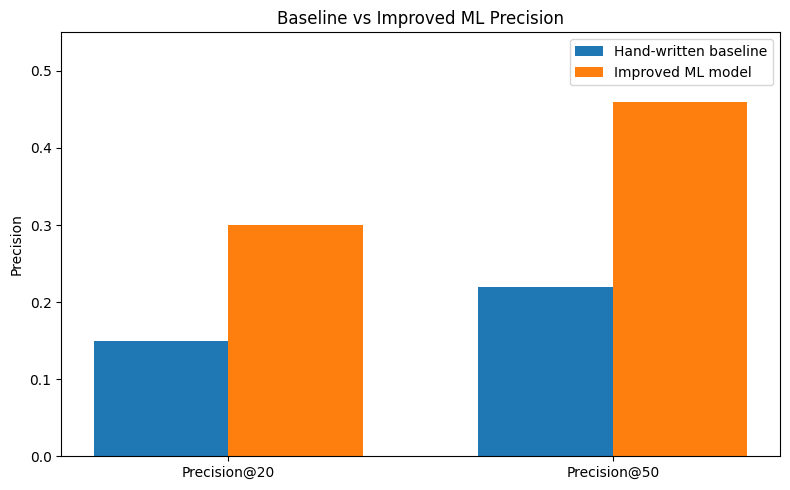

In [ ]:
# Part 7 — Artifact 1: Baseline vs Improved ML Precision

import matplotlib.pyplot as plt
import numpy as np

labels = ["Precision@20", "Precision@50"]

baseline = [0.15, 0.22]
improved_ml = [0.30, 0.46]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, baseline, width, label="Hand-written baseline")
ax.bar(x + width/2, improved_ml, width, label="Improved ML model")

ax.set_ylabel("Precision")
ax.set_title("Baseline vs Improved ML Precision")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 0.55)
ax.legend()

plt.tight_layout()
plt.show()

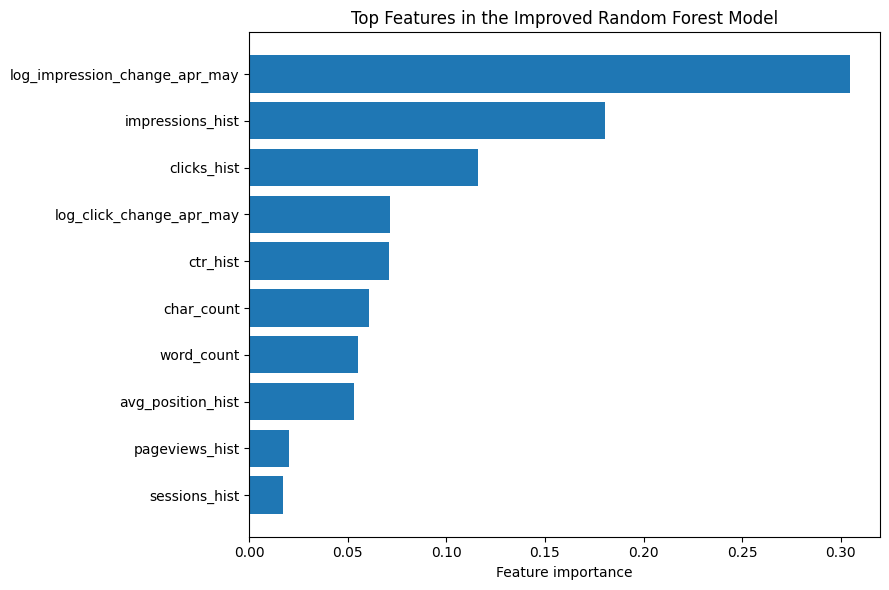

In [ ]:
# Part 7 — Artifact 2: Top Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": [
        "log_impression_change_apr_may",
        "impressions_hist",
        "clicks_hist",
        "log_click_change_apr_may",
        "ctr_hist",
        "char_count",
        "word_count",
        "avg_position_hist",
        "pageviews_hist",
        "sessions_hist"
    ],
    "importance": [
        0.304740,
        0.180661,
        0.115978,
        0.071286,
        0.071091,
        0.060641,
        0.055069,
        0.053219,
        0.020040,
        0.017021
    ]
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature importance")
plt.title("Top Features in the Improved Random Forest Model")

plt.tight_layout()
plt.show()

In [3]:
# Part 7 — Artifact 3: Ranked Recommendations

recommendations = improved_ranked.head(50).copy()

# Create reason codes
def get_reason(row):
    decline = row["impression_change_pct"]

    if decline <= -0.90:
        return "Severe impression decline"
    elif decline <= -0.80:
        return "Strong impression decline"
    elif decline <= -0.50:
        return "Moderate impression decline"
    else:
        return "Review for other signals"

recommendations["reason_code"] = recommendations.apply(
    get_reason,
    axis=1
)

# Create recommended action
def get_action(reason):
    if reason == "Severe impression decline":
        return "High-priority refresh review"
    elif reason == "Strong impression decline":
        return "Refresh review"
    elif reason == "Moderate impression decline":
        return "Monitor and investigate"
    else:
        return "Monitor"

recommendations["recommended_action"] = recommendations["reason_code"].apply(
    get_action
)

# Select only public-safe columns for the paper
recommendations = recommendations[
    [
        "rank",
        "content_hash_id",
        "improved_ml_score",
        "reason_code",
        "recommended_action",
        "impressions_hist",
        "ctr_hist",
        "avg_position_hist",
        "impression_change_pct"
    ]
].copy()

display(recommendations)

,rank,content_hash_id,improved_ml_score,reason_code,recommended_action,impressions_hist,ctr_hist,avg_position_hist,impression_change_pct
75410,1,content_86e483779bb090fc,0.888271,Review for other signals,Monitor,69.0,0.000000,30.501042,-0.376812
79675,2,content_78d762622e83b434,0.887704,Strong impression decline,Refresh review,201.0,0.000000,25.230102,-0.875622
103884,3,content_3d149327d5609856,0.885727,Strong impression decline,Refresh review,39.0,0.000000,34.977778,-0.820513
105233,4,content_542589b54e60a053,0.881041,Severe impression decline,High-priority refresh review,4315.0,0.000232,28.166483,-0.931634
75243,5,content_a3213b65f8435968,0.880578,Strong impression decline,Refresh review,846.0,0.000000,18.922924,-0.822695
108899,6,content_51adfdf993162378,0.880044,Moderate impression decline,Monitor and investigate,65.0,0.000000,19.877778,-0.538462
79552,7,content_1d97539f5d23979f,0.878160,Strong impression decline,Refresh review,251.0,0.000000,13.519273,-0.892430
75307,8,content_c52d09daf7a1a4c9,0.877075,Moderate impression decline,Monitor and investigate,24.0,0.000000,27.194444,-0.791667
115786,9,content_f57566c832af4c38,0.874708,Strong impression decline,Refresh review,39.0,0.000000,13.501587,-0.871795
108906,10,content_b658a4b822aeec73,0.872442,Severe impression decline,High-priority refresh review,1066.0,0.000000,23.134636,-0.903377


## Self-check

Before you submit, confirm each line honestly:

- ✅ Every section above is filled — markdown thinking AND the code that backs it
- ✅ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✅ No client names, URLs, or private queries anywhere
- ✅ My claims use careful words: observed, measured, directional, decision-support
- ✅ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- ✅ My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- ✅ **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
